# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [6]:
print("PRIMERAS FILAS DE PLANS")
display(plans.head())

PRIMERAS FILAS DE PLANS


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [7]:
print("\n PRIMERAS FILAS DE USERS ")
display(users.head())


 PRIMERAS FILAS DE USERS 


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [8]:
print("\n--- PRIMERAS FILAS DE USAGE ---")
display(usage.head())


--- PRIMERAS FILAS DE USAGE ---


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [9]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [10]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [11]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [12]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [13]:
print(" VALORES NULOS: USERS ")
print("Cantidad de valores nulos:")
print(users.isna().sum())

 VALORES NULOS: USERS 
Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64


In [14]:
print("Proporción de valores nulos (%):")
print(users.isna().mean() * 100)

Proporción de valores nulos (%):
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [15]:
print(" VALORES NULOS: USAGE ")
print("Cantidad de valores nulos:")
print(usage.isna().sum())

 VALORES NULOS: USAGE 
Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


In [16]:
print("\n Proporción de valores nulos (%):")
print(usage.isna().mean() * 100)


 Proporción de valores nulos (%):
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

✍️ **Comentario**:                                
churn_date (88.35% nulos):       
Comentario: La gran mayoría de los datos están ausentes porque representan a los usuarios que siguen con el servicio activo.         
Acción: Ignorar / Conservar como nulos, ya que borrar estas filas significaría eliminar al 88% de los clientes activos.

city (~11.73% nulos):             
Comentario: Son moderados los datos de ubicación faltantes.      
Acción: Imputar como 'Desconocido' para no perder la información del resto de las columnas del usuario al agrupar por ciudad

💡 " VALORES NULOS: USAGE " 
date (0.12% nulos):           
Comentario: Proporción insignificante de fechas faltantes.          
Acción: Eliminar las filas con fechas nulas (o investigar si se pueden imputar con la fecha de registro/mes correspondiente), dado que no afecta la representatividad de la muestra.

 duration (55.19% nulos) y length (44.74% nulos):                
Comentario: Proporción alta de nulos condicionada por el tipo de consumo (llamadas/mensajes o corresponden a registros de datos de internet).             
Acción: Investigar la distribución por tipo de servicio (type); para los registros donde el valor faltante sea estructural, es decir la logica que contegan (ej. un mesaje no tine duracion) imputar con 0 o mantenerlos separados según el tipo de consumo analizado.

 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [17]:
display(users.describe())

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...La edad mínima registrada es -999 (afecta a 55 registros). Este es un valor sentinel que indica datos faltantes, el cual distorsiona el promedio de edad.

In [18]:
display(usage.describe())

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...  no contiene ningún valor nulo ni duplicado.
- id es un identificador secuencial para cada evento o transacción de uso.

In [19]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print("Valores únicos en 'city':", users['city'].unique())
print("Valores únicos en 'plan':", users['plan'].unique())

Valores únicos en 'city': ['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Valores únicos en 'plan': ['Basico' 'Premium']


- La columna `city` ... Medellín, CDMX, Bogotá, GDL, MTY, Cali
- La columna `plan` ... Basico, Premium'

In [20]:
# explorar columna categórica de usage
usage['type'] 
print("Valores únicos en 'type':", usage['type'].unique())

Valores únicos en 'type': ['call' 'text']


- La columna `type` ... call, text
- la columna city     tiene valores tipo sentinels: "nana" y '?'

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  en Age y City
- ¿Qué acción tomarías?
- En age: reemplazar -999 por NaN e imputar con la mediana o media de la edad.
- En City: estandarizar sustituyendo '?' por 'Desconocido' o unificarlo con los NaN existentes.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [21]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [22]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [23]:
# Revisar los años presentes en `reg_date` de users
print("Años en reg_date (users)")
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

Años en reg_date (users)
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
En esta tabla se observa 40 registros del año 2026 y en el dataset todavia no exitia ese año

In [24]:
# Revisar los años presentes en `date` de usage
print("\nAños en date (usage):")
print(usage['date'].dt.year.value_counts(dropna=False).sort_index())


Años en date (usage):
2024.0    39950
NaN          50
Name: date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.
50 fechas faltantes

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? *Un error tipográfico*
- (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- *Ajustar el año: Restar 2 años a estas fechas específicas para corregirlas a 2024-05-10. Esto conserva la información completa del usuario*.
- **Eliminar las filas con fechas faltantes: Eliminar estos 50 registros es seguro y no altera las tendencias globales.**

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [30]:
# Reemplazar -999 por la mediana de age
import pandas as pd
import numpy as np
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [34]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()


count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [35]:
print(f"Valores '?' restantes en city: {(users['city'] == '?').sum()}")

Valores '?' restantes en city: 0


In [42]:
# Marcar fechas futuras como NA para reg_date
# Asegurarnos de que reg_date sea de tipo datetime
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT
# Verificar cambios
display(users['reg_date'].describe())

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

In [41]:
print(f"Fechas mayores a 2024 en reg_date: {(users['reg_date'].dt.year > 2024).sum()}")

Fechas mayores a 2024 en reg_date: 0


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [43]:
# Verificación MAR en usage (Missing At Random) para duration
print("Valores nuelos por tipo de servicio")
nulos_por_tipo = usage.groupby('type')[['duration', 'length']].apply(lambda x: x.isna().sum())
display(nulos_por_tipo)

Valores nuelos por tipo de servicio


,duration,length
type,,
call,0,17896
text,22076,0


In [44]:
# Verificación MAR en usage (Missing At Random) para length
print("\nRegistros totales por tipo de servicio")
print(usage['type'].value_counts())


Registros totales por tipo de servicio
text    22092
call    17908
Name: type, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Considero qu son MAR que estan intercambiado los registros, se debe aplicar un cambio de columanas, (ej. longitud 'length' pertenece a mensajes de texto 'text' y duracion 'duration' pertence a llamadas, 'call' )

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [46]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg  = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()
# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [48]:
# Renombrar columnas
usage_agg.columns = ["user_id",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada",
]
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [50]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(6)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01
5,10005,Luis,Garcia,61.0,MTY,2022-01-02 08:51:29.572393098,Basico,NaN,5.0,7.0,44.97


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [51]:
# Resumen estadístico de las columnas numéricas
# 1. Definir las columnas numéricas clave
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# 2. Obtener el resumen estadístico de las columnas numéricas

resumen_numerico = user_profile[columnas_numericas].describe().T[['mean', 'std', 'min', '50%', 'max']]
resumen_numerico = resumen_numerico.rename(columns={'50%': 'mediana'})
display(resumen_numerico)


,mean,std,min,mediana,max
age,48.136000,17.689919,18.0,48.00,79.00
cant_mensajes,5.524381,2.358416,0.0,5.00,17.00
cant_llamadas,4.478120,2.144238,0.0,4.00,15.00
cant_minutos_llamada,23.317054,18.168095,0.0,19.78,155.69


In [52]:
# Distribución porcentual del tipo de plan
distribucion_plan = user_profile['plan'].value_counts(normalize=True) * 100
display(distribucion_plan.round(2).astype(str) + '%')

Basico     64.88%
Premium    35.12%
Name: plan, dtype: object

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

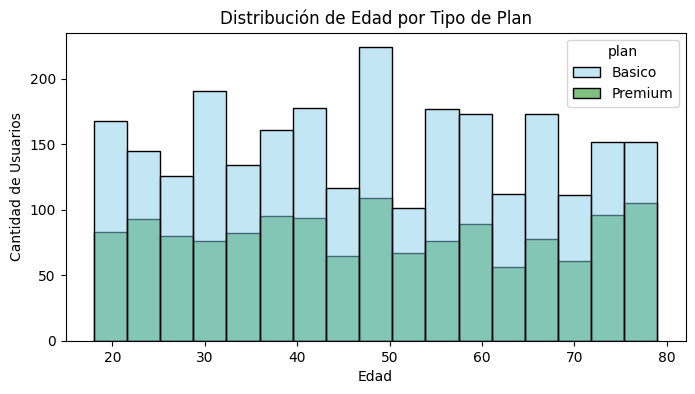

In [55]:
# Histograma para visualizar la edad (age)
import matplotlib.pyplot as plt
import seaborn as sns
paleta = ['skyblue', 'green']
plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='age', hue='plan', palette=paleta)
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- La distribución de edad es uniforme a lo largo del rango de 18 a 79 años. Tanto en el plan Básico como en el Premium, la proporción de usuarios se mantiene constante en todos los grupos de edad, lo que indica que el tipo de plan elegido no depende de la edad del clinte.
Tipo de Distribución: Simétrica / Uniforme

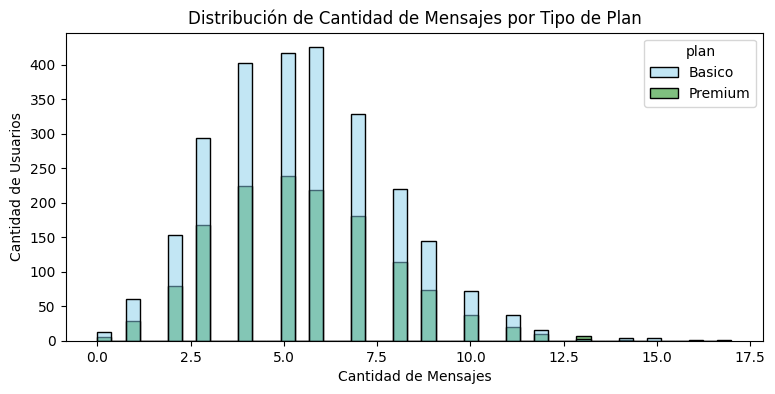

In [57]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(9, 4))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=paleta)
plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Los usuarios de ambos planes tienden a enviar entre 3 y 7 mensajes. Aunque la masa principal de usuarios corresponde al plan Básico (debido a su mayor proporción en la muestra), el comportamiento de envío es prácticamente idéntico entre clientes Básico y Premium.
Tipo de Distribución: Ligeramente sesgada a la derecha

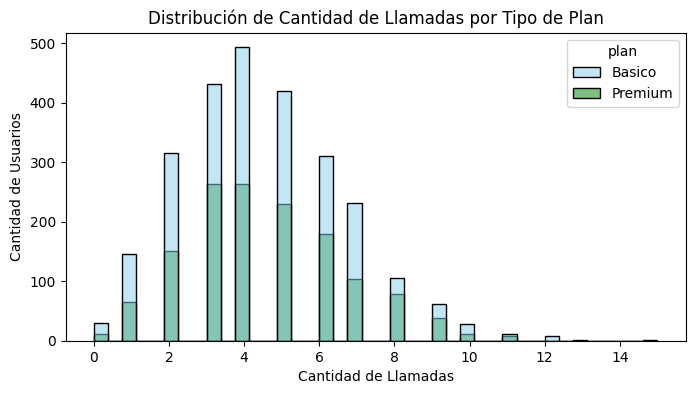

In [58]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=paleta)
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Tanto usuarios de plan Básico como Premium realizan de manera frecuente entre 2 y 6 llamadas. No existe un patrón o diferencia significativa de comportamiento en la frecuencia de llamadas entre ambos planes.
Tipo de Distribución: Ligeramente sesgada a la derecha

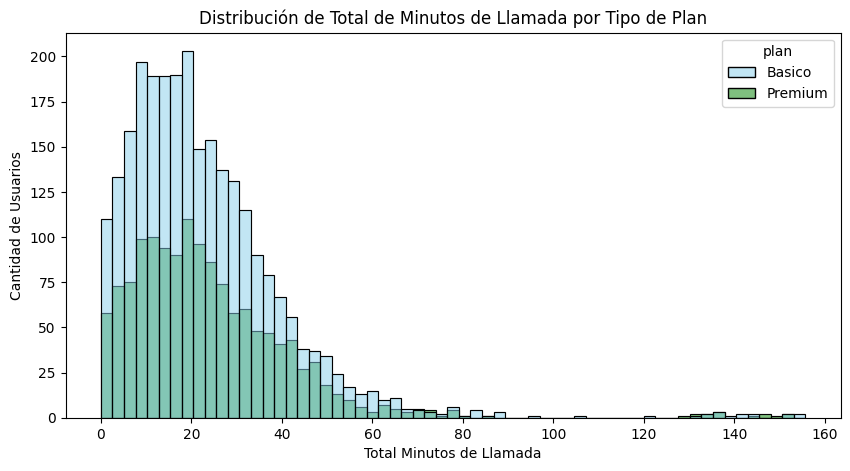

In [60]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=paleta)
plt.title('Distribución de Total de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Total Minutos de Llamada')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- La mayoría de los usuarios de ambos planes acumula entre 10 y 30 minutos de llamada. Sin embargo, existe una minoría de usuarios que supera los 60 minutos e incluso llega hasta los 155 minutos. Dentro de estos valores extremos no se observa una preferencia exclusiva por el plan Premium, sino que se distribuyen en ambos tipos de plan.

### 6.2 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.



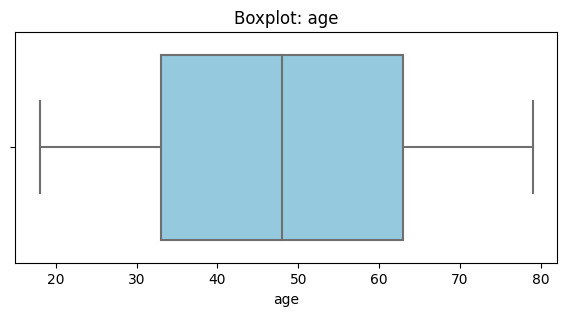

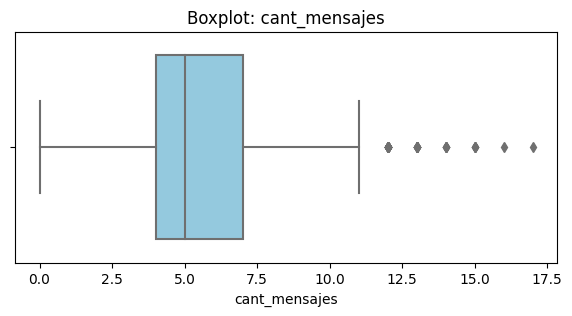

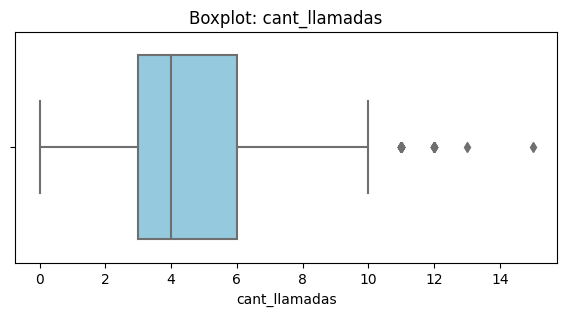

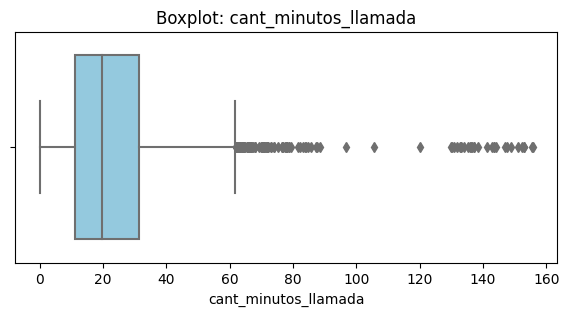

In [65]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(7, 3))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: No existen outliers. La distribución abarca de forma continua y pareja entre los 18 y 79 años.
- cant_mensajes: Sí existen outliers superiores
- cant_llamadas: Sí existen outliers superiores. Hay usuarios con un total de llamadas por encima del rango atípico
- cant_minutos_llamada: Sí existen outliers en gran cantidad. Presenta una cola larga con usuarios que acumulan entre 60 y más de 150 minutos de llamadas.

In [95]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites :
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1
    
    #  Calcular únicamente el límite superior
    limite_superior = q3 + 1.5 * iqr
    
    #  Conectar y contar cuántos outliers hay sobre el límite
    num_outliers = (user_profile[col] > limite_superior).sum()

  

In [84]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
display(user_profile[columnas_limites].describe())


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?
  * Decisión: Conservar los outliers, no eliminarlos ni recortarlos.
* Los valores atípicos detectados representan el comportamiento orgánico de usuarios de alto consumo. No corresponden a errores de medición ni a fallos en la toma de datos, sino a clientes legítimos que generan un uso intensivo de minutos, llamadas o mensajes.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [93]:
# Crear columna grupo_uso



condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),   # Bajo uso
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)  # Uso medio
]

#  Definir los nombres de los grupos para cada condición
opciones = ['Bajo uso', 'Uso medio']

# 3. Aplicar np.select asignando 'Alto uso' como valor por defecto para el resto de casos
user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')



In [94]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [99]:

def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

# Crear la columna grupo_edad
user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)


In [100]:
# verificar cambios
user_profile.head(10)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor
5,10005,Luis,Garcia,61.0,MTY,2022-01-02 08:51:29.572393098,Basico,NaN,5.0,7.0,44.97,Uso medio,Adulto Mayor
6,10006,Sofia,Lopez,39.0,Bogotá,2022-01-02 15:25:47.486871717,Basico,NaN,3.0,5.0,28.39,Uso medio,Adulto
7,10007,Sofia,Gomez,70.0,Medellín,2022-01-02 22:00:05.401350337,Premium,NaN,3.0,5.0,30.23,Uso medio,Adulto Mayor
8,10008,Sofia,Garcia,76.0,CDMX,2022-01-03 04:34:23.315828957,Basico,NaN,5.0,5.0,28.85,Uso medio,Adulto Mayor
9,10009,Mateo,Torres,47.0,Bogotá,2022-01-03 11:08:41.230307576,Basico,NaN,5.0,3.0,5.99,Uso medio,Adulto


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

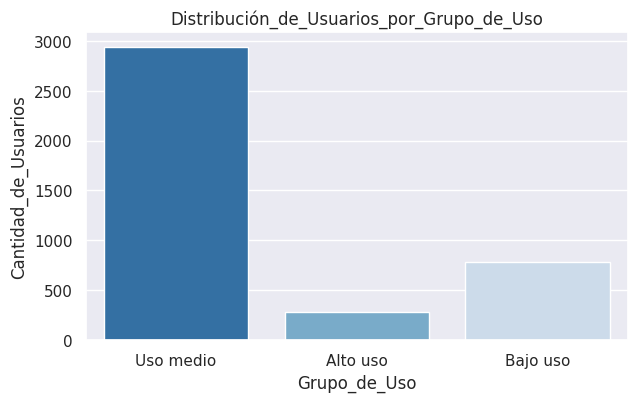

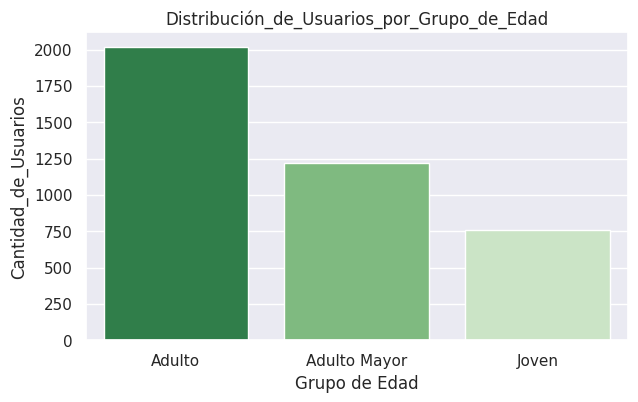

In [111]:
# Visualización de los segmentos por uso
sns.set_theme()
plt.figure(figsize=(7, 4))
sns.countplot(data=user_profile, x='grupo_uso', palette='Blues_r')
plt.title('Distribución_de_Usuarios_por_Grupo_de_Uso')
plt.xlabel('Grupo_de_Uso')
plt.ylabel('Cantidad_de_Usuarios')
plt.show()
plt.figure(figsize=(7, 4))
sns.countplot(data=user_profile, x='grupo_edad', palette='Greens_r')
plt.title('Distribución_de_Usuarios_por_Grupo_de_Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad_de_Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

La calidad y limpieza original de los datos.
Al iniciar el análisis, la base de datos presentó tres anomalías principales que fueron corregidas para no sesgar las métricas:
Sentinels en Edad [age]: Se identificó el valor sentinel -999 en 40 registros equivalentes al 1% del total de 4,000 usuarios. Fueron imputados utilizando la mediana de edad, 48 años.
Valores faltantes en Ciudad [city]: Se identificó la cadena "?" en 400 registros 10% de la base, los cuales fueron transformados a nulos estándar (pd.NA).
Fechas fuera de rango [reg_date]: Se registraron 40 casos (1%) con fechas imposibles posteriores a 2024 (ej. 2026), marcándolas adecuadamente como nulos.
Nulos estructurales [duration y length]: Se confirmó que los valores faltantes responden al tipo de evento (MAR): los mensajes no tienen duración y las llamadas no tienen longitud. Se conservaron intactos para no contaminar los promedios.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

Por Edad: La base de usuarios se distribuye de manera uniforme entre los 18 y los 79 años, dividida en tres grupos principales: Jóvenes <30 años, Adultos 30 a 59 años y Adultos Mayores >60años. La edad no condiciona la elección del plan.
Por Uso:
Bajo Uso <5 : Representa la base operativa constante.
Uso Medio <10 : El bloque con mayor volumen de clientes.
Alto Uso: Un grupo reducido pero crítico de usuarios.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

Clientes de Alto Uso en Plan Básico o Premium: Son el segmento de mayor valor operativo y comercial.
 Aunque el 64.88% de los clientes está en el Plan Básico y sólo el 35.12% en el Premium, la cantidad media de mensajes y llamadas es muy similar entre ambos planes. Esto indica que existen clientes de Alto Uso atascados en el Plan Básico, representando una oportunidad inmediata de migración a planes de mayor valor.
 
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

Hallazgo: Se detectaron outliers únicamente por la derecha, principalmente en minutos de llamada alcanzando hasta 155.69 minutos.
Implicación de negocio: No representan errores de datos, sino usuarios corporativos/comerciales. Mantenerlos en el dataset es vital porque son los clientes que más demandan estabilidad en la red y mayor margen de ganancia o consumo continuo representan.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

Lanzar una Campaña de Upgrade: Identificar a los usuarios de Alto Uso que actualmente pagan el Plan Básico y ofrecerles incentivos para migrar al Plan Premium.
Rediseño de Tarifas, plan flex: Dado que el consumo de mensajes y llamadas es relativamente moderado para la mayoría de usuarios (mediana de 5 mensajes y 4 llamadas), un plan intermedio centrado en datos/minutos podría capturar mejor a la masa de uso medio.
Planes Corporativos : Crear un plan con minutos ilimitados o un paquete de voz preferencial dirigido específicamente al segmento atípico (outliers de >60 minutos), garantizándoles fidelización y evitando que migren a la competencia.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Datos sentinels e inconsistentes: Se detectaron 40 registros (1%) con edad sentinel (-999), 400 registros (10%) con ciudad no identificada ("?") y 40 registros (1%) con fechas de registro futuras imposibles.
- Nulos estructurales (MAR): Se confirmó que la ausencia de datos en duration y length depende del tipo de servicio mensajes no tienen duración y llamadas no tienen caracteres, por lo que se mantuvieron nulos para no distorsionar las métricas reales.


🔍 **Segmentos por Edad**
- Comportamiento uniforme: La base de clientes se distribuye homogéneamente entre 18 y 79 años, dividida en Jóvenes -30, Adultos 30-59 y Adultos Mayores 60+.
- Independencia del plan: La edad no es un factor determinante al momento de elegir entre el plan Básico o Premium; la proporción de edades es similar en ambos grupos.


📊 **Segmentos por Nivel de Uso**
- Concentración en Bajo y Medio uso: La mayoría de los clientes realiza entre 2 y 6 llamadas y envía entre 3 y 7 mensajes, mostrando hábitos de consumo moderados
- Presencia de Outliers: Existe un grupo minoritario de **alto uso** que alcanza hasta 155 minutos de llamadas acumuladas, representando clientes corporativos o de alta demanda vocal.


➡️ Esto sugiere que: Existe una desconexión entre el tipo de plan contratado y el consumo real. Un 64.88% de los clientes está en el plan Básico, pero muchos de ellos muestran un nivel de consumo de mensajes y llamadas idéntico al de los clientes del plan Premium, lo que indica un potencial desaprovechado de migración de plan (upselling).


💡 **Recomendaciones**
- Campaña de Upselling focalizada: Identificar a los usuarios clasificados en el segmento de Alto uso que actualmente se encuentran en el plan Básico y ofrecerles promociones exclusivas para migrar al plan Premium.
- Paquetes a la medida para Usuarios de alto consumo o premium ejecutiv: Diseñar un plan o módulo adicional de minutos ilimitados orientado a retener a los clientes de consumo extremo (outliers superiores), evitando que migren hacia la competencia. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`